# Hydrogen Storage

general formula:
P + n^2/V^2 = (nRT)/(V-nb)

with:
a = 0.2476 [L^2bar/mol^2] and 
b = 0.02661 [L/mol]


and n = 
### Hydrogen storage at the green village


In [2]:
import numpy as np

a = 0.2476/10  # Pa·M^6/mol^2
b = 0.02661/1000  # M^3/mol
V = 53*50/1000 # m^3 L (50 L)
P = 270e5 # Pa
n = 0 # moles of Hydrogen
R = 8.314 # J/molK
T = 298 # K
M = 2.016 # g/mol
LHV = 33.3 # kWh/kg
LHV = 120 # MJ/kg


n = P*V/(R*T)
mass = n * M / 1000  # kg
energy = mass * LHV*1000/3600  # kWh

# Display results
print(f"Real roots for n (number of moles) {n:.2f}:")
print(f"mass content: {mass:.2f} [kg]")
print(f"Energy content: {energy:.2f} [kWh]")

Real roots for n (number of moles) 28879.08:
mass content: 58.22 [kg]
Energy content: 1940.67 [kWh]


### Toyota Miraj

In [4]:
# Capacity
import numpy as np

a = 0.2476/10  # Bar·L^2/mol^2
b = 0.02661/1000  # L/mol
V = 122.4/1000 # M3
P = 700e5
n = 0 # moles of Hydrogen
R = 8.314 # J/molK
T = 298 # K
M = 2.016 # g/mol
LHV = 33.3 # MJ/kg


n = P*V/(R*T)
mass = n * M / 1000  # kg
energy = mass * LHV*1000/3600  # kWh

# Display results
print(f"Real roots for n (number of moles) {n:.2f}:")
print(f"mass content: {mass:.2f} [kg]")
print(f"Energy content: {energy:.2f} [kWh]")

Real roots for n (number of moles) 3458.22:
mass content: 6.97 [kg]
Energy content: 64.49 [kWh]


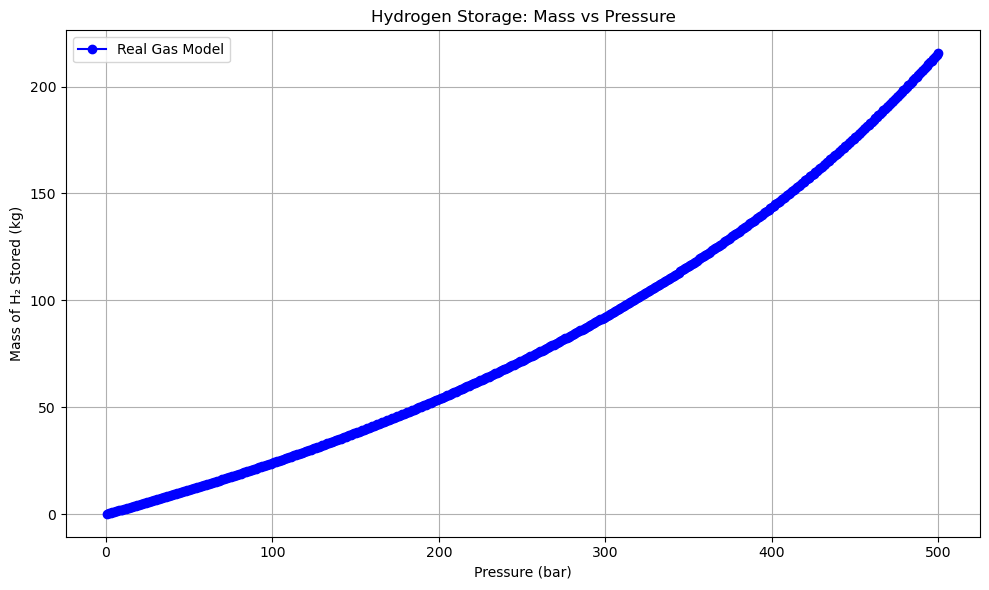

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
R = 8.314  # J/(mol·K) Gas constant
M_H2 = 2.016  # [g/mol]
volume = 53*50/1000 # [m3] capacity
temperature = 298.15  # [K] Temperature
pressure_min = 1  # Min pressure [bar]
pressure_max = 500 # Max pressure [bar]
pressure_step = 1  # Pressure step [bar]

pressures = np.arange(pressure_min, pressure_max + pressure_step, pressure_step) * 1e5 # min to max bar to Pa


def compressibility_factor(P):
    return 1 - (P / 1e7) * 0.1

# Calculate mass of hydrogen stored
mass_h2 = []
for P in pressures:
    Z = compressibility_factor(P)
    n_h2 = (P * volume) / (Z * R * temperature)  # [Mol] H2
    mass = n_h2 * M_H2/1000  # [kg] of H2
    mass_h2.append(mass)

# Convert results to arrays
pressures_bar = pressures / 1e5  # Convert pressures back to bar for plotting
mass_h2 = np.array(mass_h2)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(pressures_bar, mass_h2, marker='o', linestyle='-', color='blue', label="Real Gas Model")
plt.title("Hydrogen Storage: Mass vs Pressure")
plt.xlabel("Pressure (bar)")
plt.ylabel("Mass of H₂ Stored (kg)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_47783/631795008.py:26: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  return fsolve(van_der_waals, n_initial)[0]
/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_47783/631795008.py:26: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  return fsolve(van_der_waals, n_initial)[0]


ValueError: x and y must have same first dimension, but have shapes (500,) and (350,)

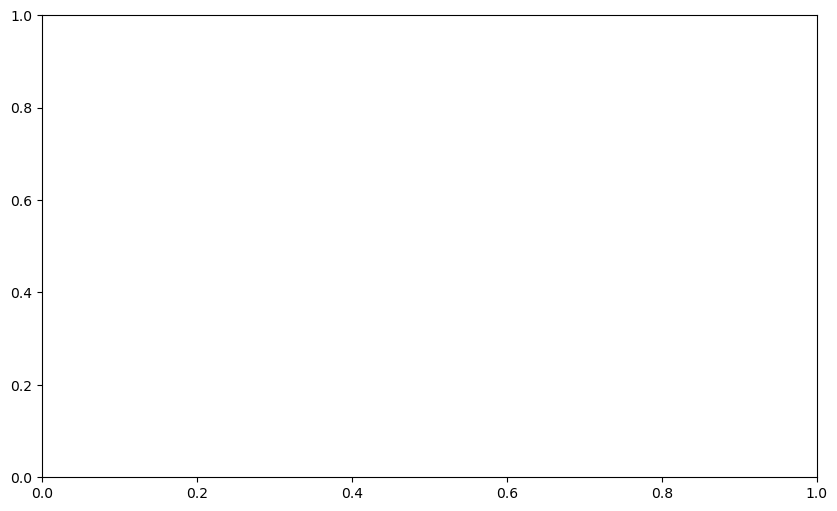

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Constants
R = 8.314  # [J/(mol·K)] gas constant
M = 2.016  # [g/mol] Molar mass of hydrogen, 
a = 0.244  # [Pa·m³/mol²]
b = 2.7e-5  # [m³/mol]

# Input parameters
V = 53*50 / 1000  # [m³]
T = 298.15  # Temperature in Kelvin (25°C)
pressure_min = 1  # Minimum pressure in bar
pressure_max = 350  # Maximum pressure in bar
pressure_step = 1  # Pressure step in bar

# Pressure range in Pascals
pressures = np.arange(pressure_min, pressure_max + pressure_step, pressure_step) * 1e5

# Function to solve Van der Waals equation for n (moles)
def solve_van_der_waals(P, V, T):
    def van_der_waals(n):
        return (P + a * (n / V)**2) * (V - n * b) - n * R * T
    n_initial = P * V / (R * T)
    return fsolve(van_der_waals, n_initial)[0]

# Calculate mass of hydrogen stored
mass_h2 = []
for P in pressures:
    n_h2 = solve_van_der_waals(P, V, T)  # Moles of H2
    mass = n_h2 * M /1000 # Mass of H2 in kg
    mass_h2.append(mass)

# Convert results to arrays
pressure_bar = pressures / 1e5  # Convert pressures back to bar for plotting
mass_h2 = np.array(mass_h2)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(pressures_bar, mass_h2, marker='o', linestyle='-', color='green', label="Van der Waals Model")
plt.title("Hydrogen Storage: Mass vs Pressure (Van der Waals)")
plt.xlabel("Pressure (bar)")
plt.ylabel("Mass of H₂ Stored (kg)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

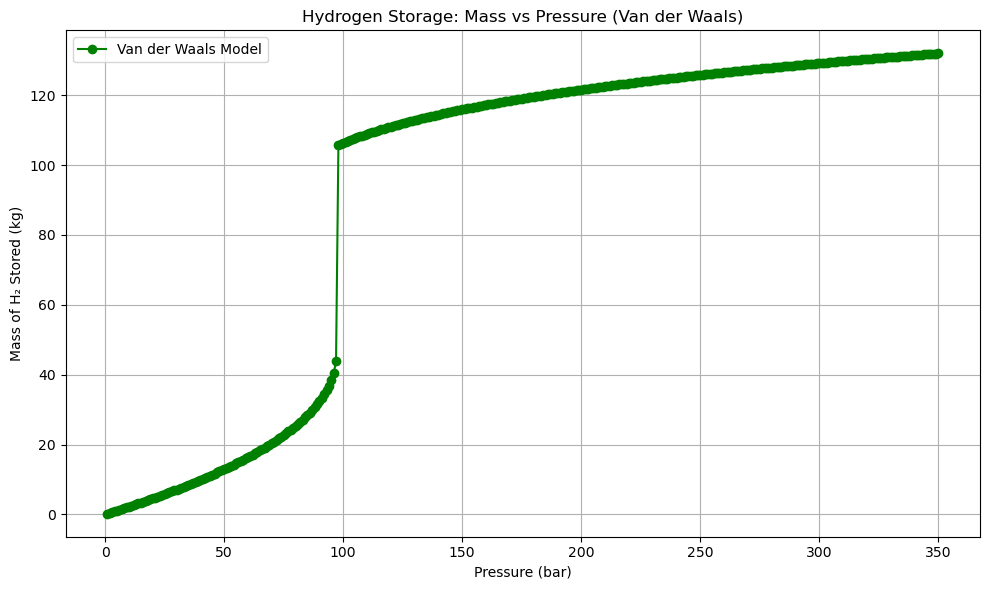

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Constants
R = 8.314  # Universal gas constant, J/(mol·K)
M_H2 = 2.016 / 1000  # Molar mass of hydrogen, kg/mol

# Van der Waals constants for hydrogen
a = 0.244  # Pa·m³/mol²
b = 2.7e-5  # m³/mol

# Input parameters
volume = 53*50/1000  # Storage tank volume in m³
temperature = 298.15  # Temperature in Kelvin (25°C)
pressure_min = 1  # Minimum pressure in bar
pressure_max = 350  # Maximum pressure in bar
pressure_step = 1  # Pressure step in bar

# Pressure range in Pascals
pressures = np.arange(pressure_min, pressure_max + pressure_step, pressure_step) * 1e5

# Function to solve Van der Waals equation for n (moles)
def solve_van_der_waals(P, V, T):
    def van_der_waals(n):
        return (P + a * (n / V)**2) * (V - n * b) - n * R * T
    
    # Initial guess from ideal gas law
    n_initial = P * V / (R * T)
    
    # Use root_scalar with a bounded interval
    result = root_scalar(van_der_waals, method='brentq', bracket=[1e-8, 1e5])  # Bracket defines reasonable mole range
    if result.converged:
        return result.root
    else:
        raise ValueError(f"Failed to converge for P={P} Pa")

# Calculate mass of hydrogen stored
mass_h2 = []
for P in pressures:
    try:
        n_h2 = solve_van_der_waals(P, volume, temperature)  # Moles of H2
        mass = n_h2 * M_H2  # Mass of H2 in kg
        mass_h2.append(mass)
    except ValueError as e:
        print(e)
        mass_h2.append(np.nan)  # Append NaN for failed calculations

# Convert results to arrays
pressures_bar = pressures / 1e5  # Convert pressures back to bar for plotting
mass_h2 = np.array(mass_h2)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(pressures_bar, mass_h2, marker='o', linestyle='-', color='green', label="Van der Waals Model")
plt.title("Hydrogen Storage: Mass vs Pressure (Van der Waals)")
plt.xlabel("Pressure (bar)")
plt.ylabel("Mass of H₂ Stored (kg)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()